In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (15,6)
plt.rcParams["font.size"] = 11

In [9]:
df1 = pd.read_excel("datasets/QatarClayBricksCo-1222227.xlsx", header=2)
df2 = pd.read_excel("datasets/RashidNasser-103122.xlsx", header=2)
df3 = pd.read_excel("datasets/EzdanHoldingGroup-1366715.xlsx", header=2)
df4 = pd.read_excel("datasets/DukhanBank-1339731.xlsx", header=2)
df5 = pd.read_excel("datasets/MinistryOfMunicipality-1131476.xlsx", header=2)

In [10]:
print(df1.columns)

Index(['Hourly', 'Consumption m3'], dtype='str')


In [11]:
time_col = "Hourly"
cons_col = "Consumption m3"

In [12]:
datasets = [df1, df2, df3, df4, df5]
names = ["Dataset 1", "Dataset 2", "Dataset 3", "Dataset 4", "Dataset 5"]

for df in datasets:
    
    df[time_col] = pd.to_datetime(df[time_col])

    df.sort_values(time_col, inplace=True)

    df["Month"] = df[time_col].dt.to_period("M")

    df["Date"] = df[time_col].dt.date

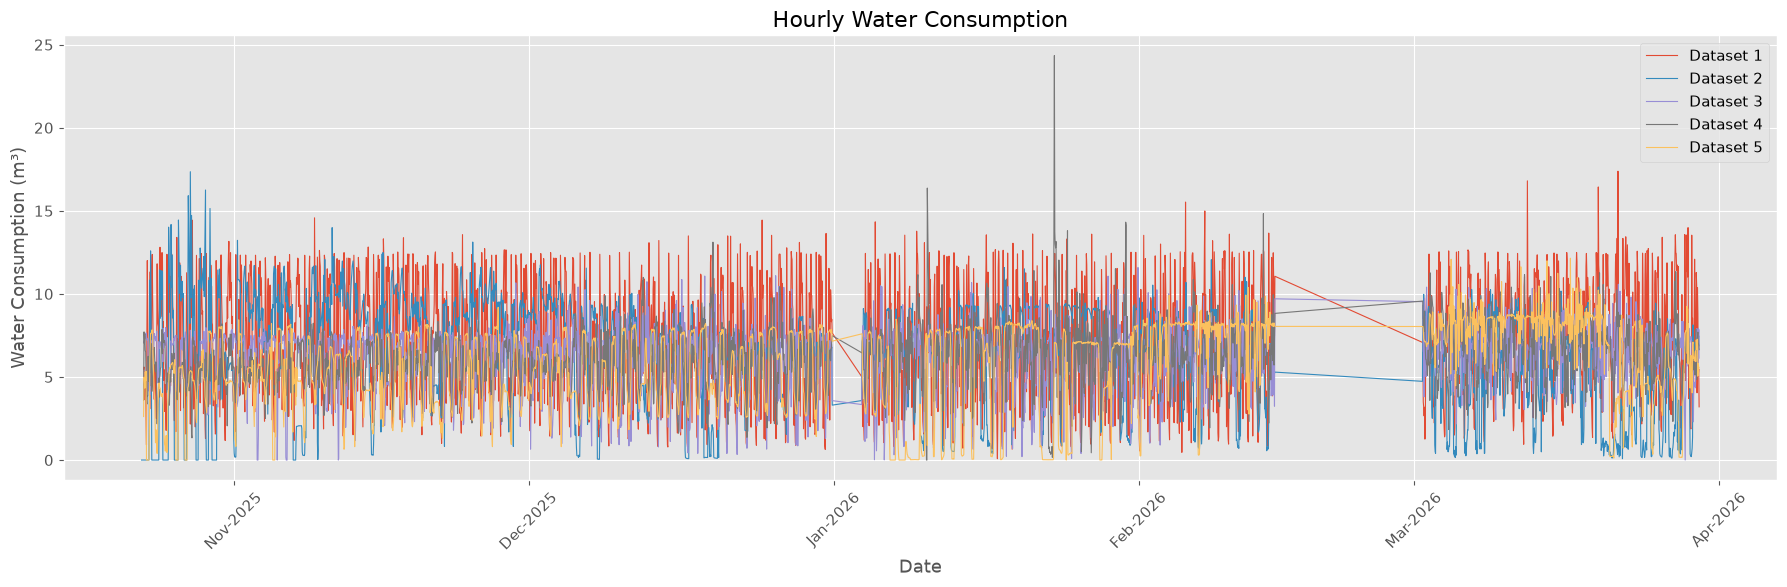

In [13]:
fig, ax = plt.subplots(figsize=(18,6))

for df, name in zip(datasets, names):

    ax.plot(
        df[time_col],
        df[cons_col],
        label=name,
        linewidth=0.8
    )

ax.set_title("Hourly Water Consumption")
ax.set_xlabel("Date")
ax.set_ylabel("Water Consumption (m³)")

ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
monthly_totals = []

for df in datasets:

    monthly = (
        df.groupby("Month")[cons_col]
        .sum()
    )

    monthly_totals.append(monthly)

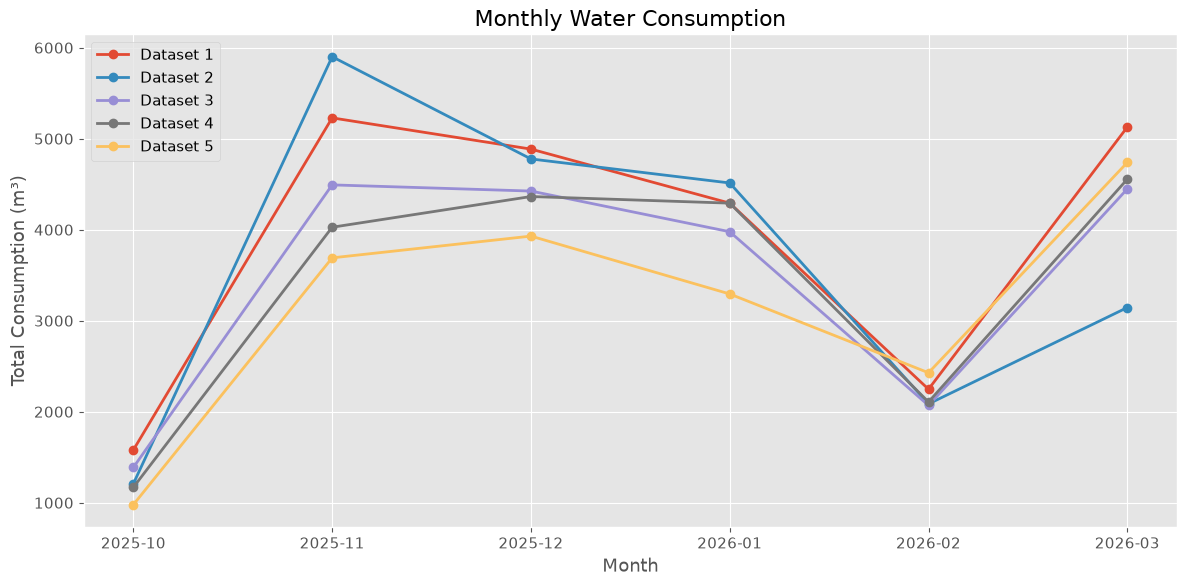

In [15]:
fig, ax = plt.subplots(figsize=(12,6))

for monthly, name in zip(monthly_totals, names):

    ax.plot(
        monthly.index.astype(str),
        monthly.values,
        marker="o",
        linewidth=2,
        label=name
    )

ax.set_title("Monthly Water Consumption")

ax.set_xlabel("Month")

ax.set_ylabel("Total Consumption (m³)")

ax.legend()

plt.tight_layout()

plt.show()

In [16]:
totals = []

for df in datasets:

    totals.append(df[cons_col].sum())

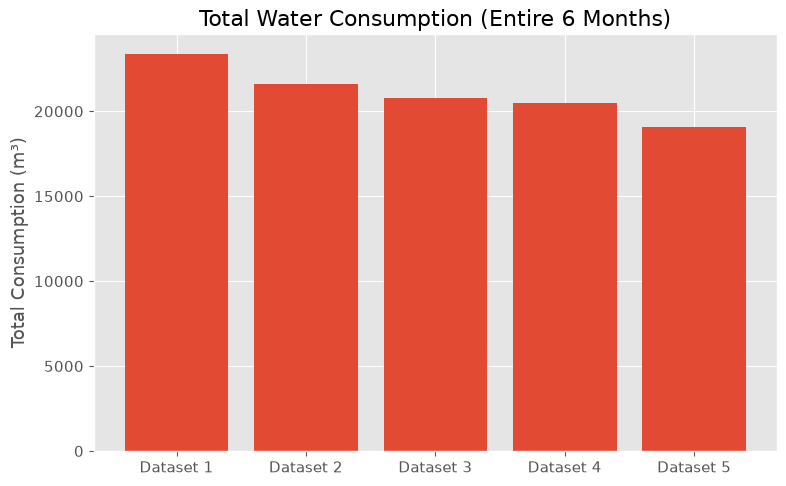

In [17]:
plt.figure(figsize=(8,5))

plt.bar(names, totals)

plt.ylabel("Total Consumption (m³)")

plt.title("Total Water Consumption (Entire 6 Months)")

plt.tight_layout()

plt.show()

In [18]:
daily_minimums = []

for df in datasets:

    daily = (
        df.groupby("Date")[cons_col]
        .min()
    )

    daily_minimums.append(daily)

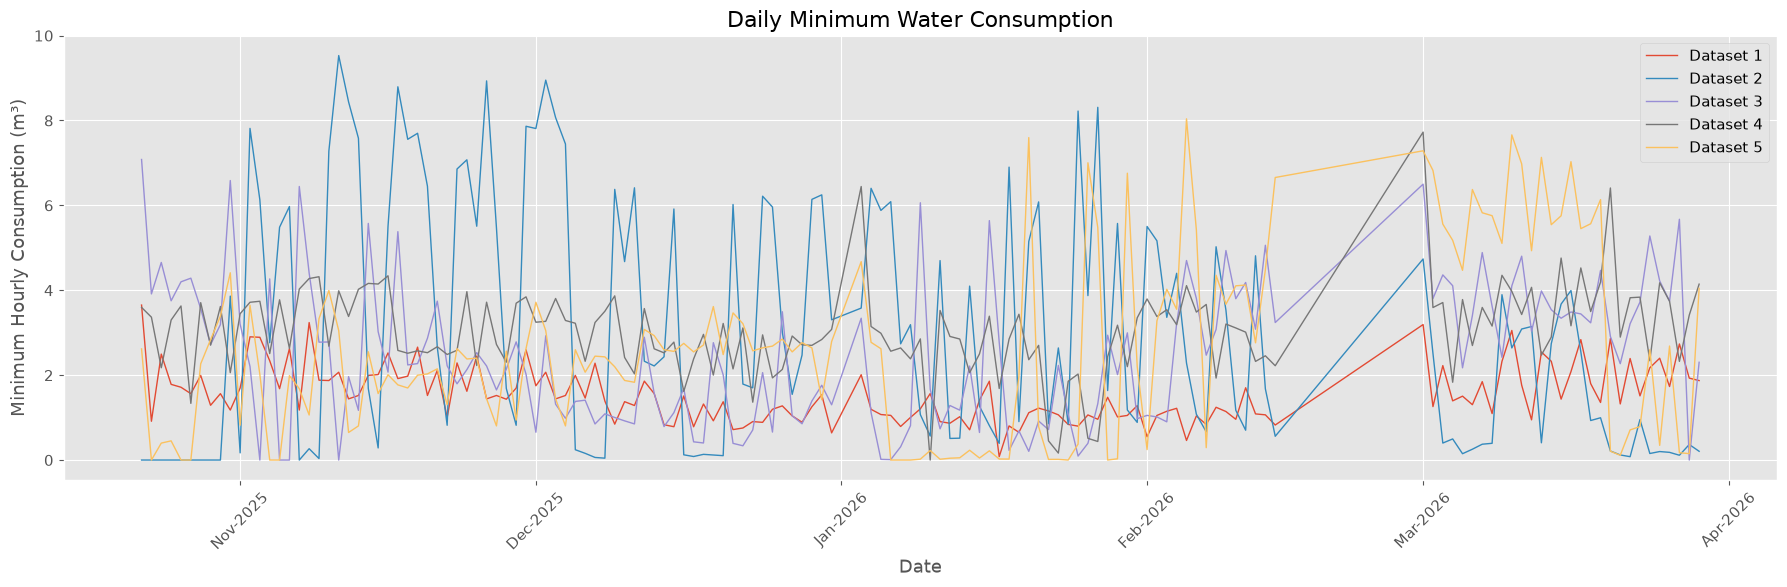

In [19]:
fig, ax = plt.subplots(figsize=(18,6))

for daily, name in zip(daily_minimums, names):

    ax.plot(
        pd.to_datetime(daily.index),
        daily.values,
        label=name,
        linewidth=1
    )

ax.set_title("Daily Minimum Water Consumption")

ax.set_xlabel("Date")

ax.set_ylabel("Minimum Hourly Consumption (m³)")

ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator())

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [20]:
for monthly, name in zip(monthly_totals, names):

    print("\n", name)

    print(monthly)


 Dataset 1
Month
2025-10    1580.347
2025-11    5228.999
2025-12    4885.872
2026-01    4292.166
2026-02    2247.508
2026-03    5127.706
Freq: M, Name: Consumption m3, dtype: float64

 Dataset 2
Month
2025-10    1209.567
2025-11    5900.865
2025-12    4777.712
2026-01    4513.737
2026-02    2085.884
2026-03    3144.973
Freq: M, Name: Consumption m3, dtype: float64

 Dataset 3
Month
2025-10    1388.212
2025-11    4492.718
2025-12    4424.856
2026-01    3977.867
2026-02    2069.403
2026-03    4448.404
Freq: M, Name: Consumption m3, dtype: float64

 Dataset 4
Month
2025-10    1169.848
2025-11    4027.413
2025-12    4364.804
2026-01    4292.038
2026-02    2107.195
2026-03    4555.336
Freq: M, Name: Consumption m3, dtype: float64

 Dataset 5
Month
2025-10     979.223
2025-11    3690.980
2025-12    3929.905
2026-01    3294.046
2026-02    2428.131
2026-03    4739.070
Freq: M, Name: Consumption m3, dtype: float64


In [21]:
summary = pd.DataFrame({
    "Dataset": names,
    "Total Consumption (m³)": totals
})

summary

,Dataset,Total Consumption (m³)
0,Dataset 1,23362.598
1,Dataset 2,21632.738
2,Dataset 3,20801.460
3,Dataset 4,20516.634
4,Dataset 5,19061.355


In [22]:
for daily, name in zip(daily_minimums, names):

    print("\n", name)

    print(daily.head())


 Dataset 1
Date
2025-10-22    3.651
2025-10-23    0.914
2025-10-24    2.496
2025-10-25    1.783
2025-10-26    1.715
Name: Consumption m3, dtype: float64

 Dataset 2
Date
2025-10-22    0.0
2025-10-23    0.0
2025-10-24    0.0
2025-10-25    0.0
2025-10-26    0.0
Name: Consumption m3, dtype: float64

 Dataset 3
Date
2025-10-22    7.081
2025-10-23    3.914
2025-10-24    4.655
2025-10-25    3.752
2025-10-26    4.199
Name: Consumption m3, dtype: float64

 Dataset 4
Date
2025-10-22    3.596
2025-10-23    3.366
2025-10-24    2.174
2025-10-25    3.299
2025-10-26    3.630
Name: Consumption m3, dtype: float64

 Dataset 5
Date
2025-10-22    2.619
2025-10-23    0.000
2025-10-24    0.399
2025-10-25    0.452
2025-10-26    0.000
Name: Consumption m3, dtype: float64
